In [171]:
# %% Import the libraries we need
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import numpy as np

# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location
dataset = pd.read_parquet("dataset/renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])

# Optional: inspect the first rows
dataset.head()


,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,solar_rel_prod,wind_rel_prod,latitude,longitude,country,solar_layout_MW,wind_layout_MW
0,2012-01-01 00:00:00+00:00,1,75.6549,9.150821,0.0,18.301642,0.0,0.0284,42.094674,-8.113982,POR,982.8607,644.4240
1,2012-01-01 00:00:00+00:00,2,557.8868,6.196411,0.0,12.392822,0.0,0.0103,41.587435,-8.326462,POR,1361.0601,1203.1866
2,2012-01-01 00:00:00+00:00,3,15.5237,6.855084,0.0,13.710167,0.0,0.0283,41.585994,-6.722728,POR,746.4879,484.4582
3,2012-01-01 00:00:00+00:00,4,8.6425,7.824092,0.0,15.648183,0.0,0.0408,41.597684,-6.342848,POR,456.1251,383.5339
4,2012-01-01 00:00:00+00:00,5,85.3649,2.053690,0.0,4.107380,0.0,0.0092,41.373957,-7.350949,POR,986.4986,446.4544


In [172]:
def maxima_values(series):
    peak_indices, _ = find_peaks(series)
    return series[peak_indices]


Text(0.5, 1.0, 'Next power peak against current peak (Node ID=1)')

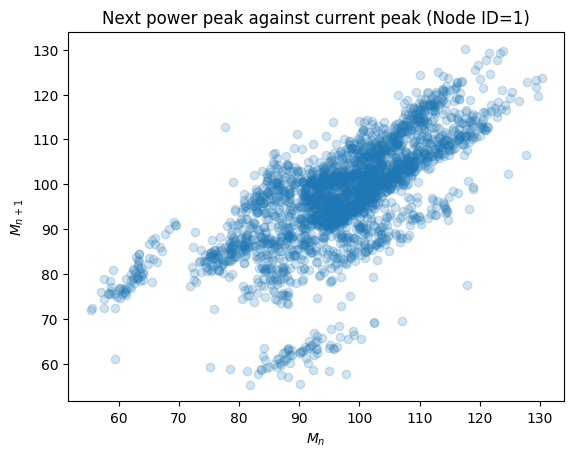

In [173]:
M_true = maxima_values(dataset[(dataset["ID"]=="1")]["demand_MWh"].to_numpy())
plt.scatter(M_true[:-1], M_true[1:], alpha=0.2)
plt.xlabel(r"$M_{n}$")
plt.ylabel(r"$M_{n+1}$")
plt.title("Next power peak against current peak (Node ID=1)")

In [174]:
dataset['row'] = dataset.groupby('ID').cumcount()

cols = dataset['ID'].unique()

out = dataset.pivot(index='row', columns='ID', values='demand_MWh')
out = out.reindex(columns=cols)


In [175]:
id_corrmat = out[out.columns[1:1000]].corr()

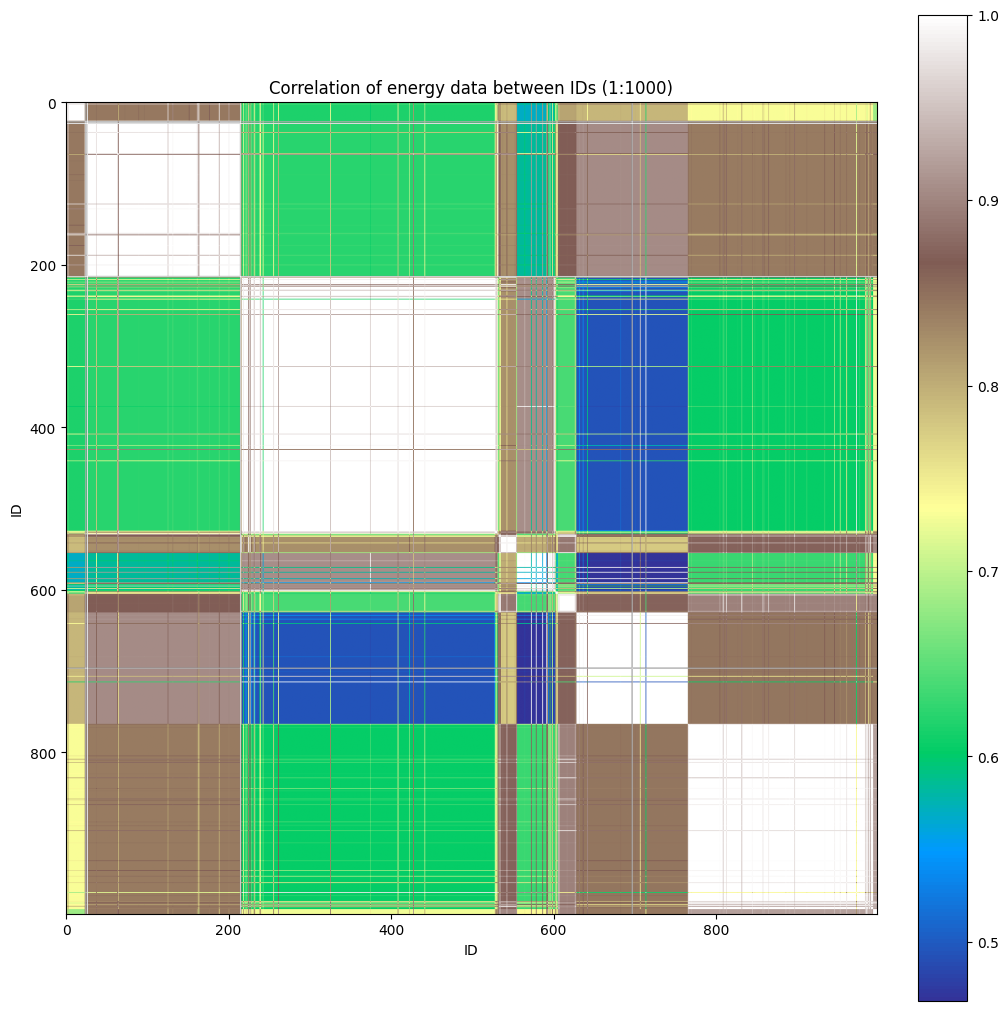

In [176]:
fig, ax = plt.subplots(figsize=(10,10), layout="constrained")
im = ax.imshow(id_corrmat, cmap="terrain")
ax.set_xlabel("ID")
ax.set_ylabel("ID")
fig.colorbar(im, ax=ax)
plt.title("Correlation of energy data between IDs (1:1000)")
plt.show()

In [177]:
plot_data = dataset[dataset["ID"]=="1"][["Time", "solar_MWh", "wind_MWh"]]

In [178]:
plot_data['hour'] = plot_data['Time'].apply(lambda x: x.hour)

In [179]:
plot_data['date'] = pd.to_datetime(plot_data['Time'].apply(lambda x: x.date()))

In [180]:
solar_gen_data = plot_data.pivot(columns="hour", index="date", values = "solar_MWh")

In [181]:
import plotnine as gg

In [190]:
def custom_label_date(x):
    return [
        d.strftime("%d-%b") if d.day == 1 else str(d.day)
        for d in x
    ]

def custom_label_time(x):
    out = []
    for h in x:
        if int(h)==0:
            out.append("12 AM")
        elif int(h)==12:
            out.append("12 PM")
        else:
            out.append(
                str(int(h) % 12)
            )
    return out

In [194]:
plot_data

,Time,solar_MWh,wind_MWh,hour,date
0,2012-01-01 00:00:00+00:00,0.0,18.301642,0,2012-01-01
1494,2012-01-01 01:00:00+00:00,0.0,21.652646,1,2012-01-01
2988,2012-01-01 02:00:00+00:00,0.0,25.261421,2,2012-01-01
4482,2012-01-01 03:00:00+00:00,0.0,27.323578,3,2012-01-01
5976,2012-01-01 04:00:00+00:00,0.0,30.610140,4,2012-01-01
...,...,...,...,...,...
39290706,2014-12-31 19:00:00+00:00,0.0,6.830894,19,2014-12-31
39292200,2014-12-31 20:00:00+00:00,0.0,8.506397,20,2014-12-31
39293694,2014-12-31 21:00:00+00:00,0.0,7.539761,21,2014-12-31
39295188,2014-12-31 22:00:00+00:00,0.0,6.766452,22,2014-12-31


0            True
1494         True
2988         True
4482         True
5976         True
            ...  
39290706    False
39292200    False
39293694    False
39295188    False
39296682    False
Name: date, Length: 26304, dtype: bool

In [214]:
    # + gg.scale_fill_gradient2(low = "blue", mid = "white", high = "red") \
p = gg.ggplot(
    plot_data[(plot_data["date"] >= pd.to_datetime("2012-01-01")) &  (plot_data["date"] <= pd.to_datetime("2012-02-01"))],
    gg.aes(
        x="hour",
        y="date",
        fill="wind_MWh",
    )
) \
    + gg.geom_raster() \
    + gg.scale_fill_continuous("coolwarm") \
    + gg.theme_minimal() \
    + gg.geom_tile(color = "white", size = 0.5) \
    + gg.theme(legend_position="top",
                panel_grid_major = gg.element_blank(),
                panel_grid_minor = gg.element_blank(),
                panel_border = gg.element_blank(),
                panel_background = gg.element_blank(),
                figure_size=(10,10)) \
    + gg.scale_y_datetime(
        breaks=pd.date_range("2012-01-01","2012-02-01"),
        labels=custom_label_date) \
    + gg.scale_x_continuous(
        breaks=np.arange(0,24),
        labels=custom_label_time
    )

p.save("jan12")

/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: jan12


In [229]:
months = ["2014-01-01", "2014-02-01", "2014-03-01", "2014-04-01", "2014-05-01", "2014-06-01", "2014-07-01","2014-08-01","2014-09-01","2014-10-01","2014-11-01","2014-12-01", "2014-12-31"]

In [230]:
plot_data["wind_MWh"].min()

np.float64(0.8377511999999999)

In [231]:
for idx, month in enumerate(months):
    if idx==12:
        break
    p = gg.ggplot(
    plot_data[(plot_data["date"] >= pd.to_datetime(month)) &  (plot_data["date"] <= pd.to_datetime(months[idx+1]))],
    gg.aes(
        x="hour",
        y="date",
        fill="wind_MWh",
    )
) \
    + gg.geom_raster() \
    + gg.scale_fill_continuous("coolwarm", limits=(0,650)) \
    + gg.theme_minimal() \
    + gg.geom_tile(color = "white", size = 0.5) \
    + gg.theme(legend_position="top",
                panel_grid_major = gg.element_blank(),
                panel_grid_minor = gg.element_blank(),
                panel_border = gg.element_blank(),
                panel_background = gg.element_blank(),
                figure_size=(10,10)) \
    + gg.scale_y_datetime(
        breaks=pd.date_range(month,months[idx+1]),
        labels=custom_label_date) \
    + gg.scale_x_continuous(
        breaks=np.arange(0,24),
        labels=custom_label_time
    )

    p.save(month, dpi=300)

/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: 2014-01-01
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: 2014-02-01
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: 2014-03-01
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 10 in image.
/Users/phc25/Documents/Git/jamboree/venv/lib/python3.14/site